# Principles of Data Science | Homework Assignment 4 (HA4): Societal Mood under COVID-19 Pandemic

For this assignment, we will dive further into using sentiment analysis as a means to gauge societal reactions to major events. Here, we will be using a different sentiment analysis tool called [VADER](https://ojs.aaai.org/index.php/ICWSM/article/view/14550). This tool is an extension of a lexicon-based approach that also takes the context of the words into account. It scores texts on an affective scale from `-1` (negative) to `1` (positive). 

In our analysis, we will use an extended data set from a [study](https://www.jmir.org/2020/12/e21418/) that performed a longitudinal analysis on the mental health in the US during the COVID-19 pandemic, by focussing on the sentiment as expressed by accounts that indicated their location was one of twenty major cities in the US.

First we load the necessary python packages

In [2]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import statsmodels.formula.api as smf

tab20 = plt.get_cmap("tab20").colors

_PANDEMIC_DATE = pd.Timestamp("11 March 2020")

### Exercise 1. (*3pt*)
The file `HA4_daily_average_VADER.tsv` contains the day-to-day VADER averages for all observed tweets for that city in the data set. Moreover, `HA4_daily_num_obs.tsv` contains the number of observed tweets for each city on a daily basis. Load these files into the variables `means` and `counts`, respectively. Make sure that you convert the index from strings into a datetime format.

Use this data to calculate the daily average of VADER scores across all cities, using the colors in the variable `tab20` as colors for the individual cities. Finally, include a dashed line plot (colored: black) that shows a rolling 7 day average of the overall average time series.

#### Solution

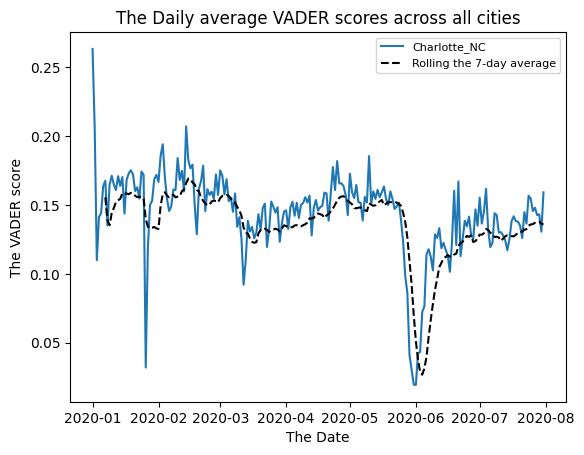

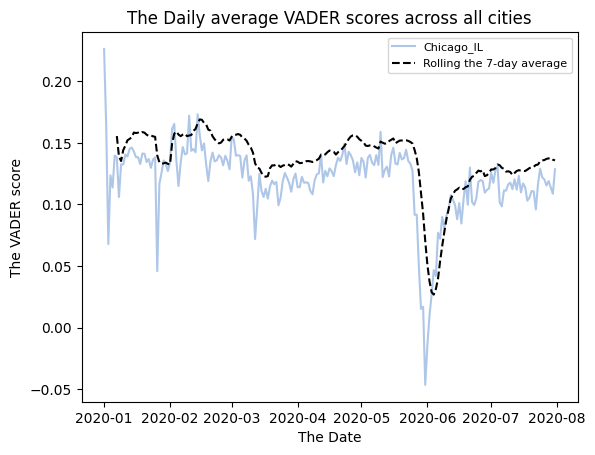

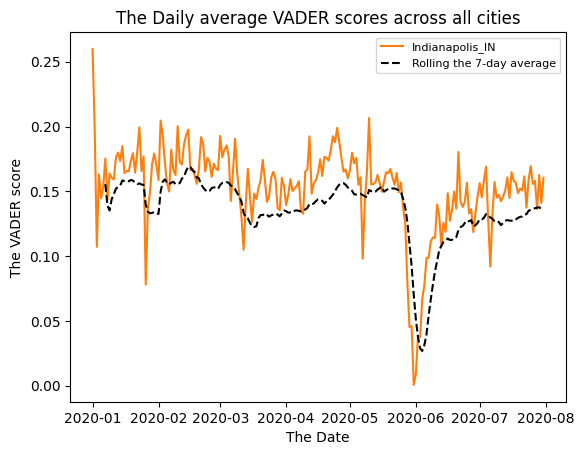

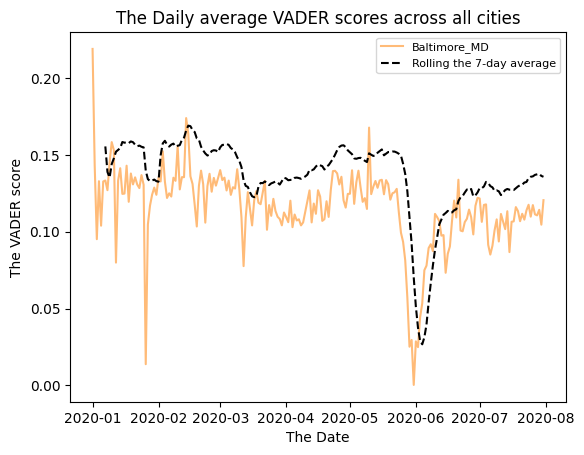

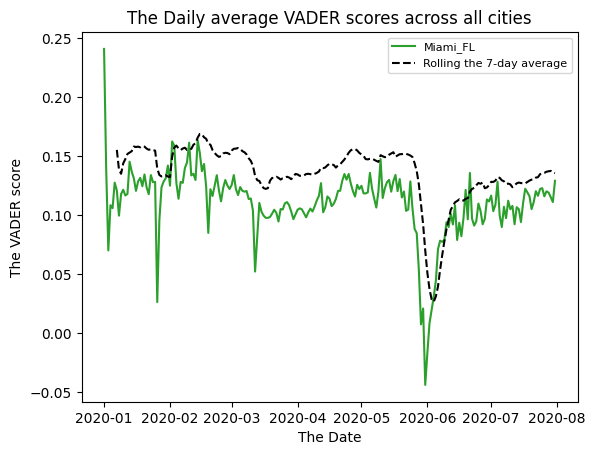

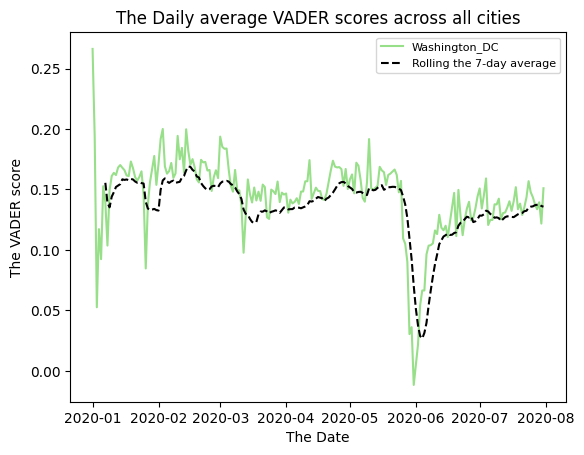

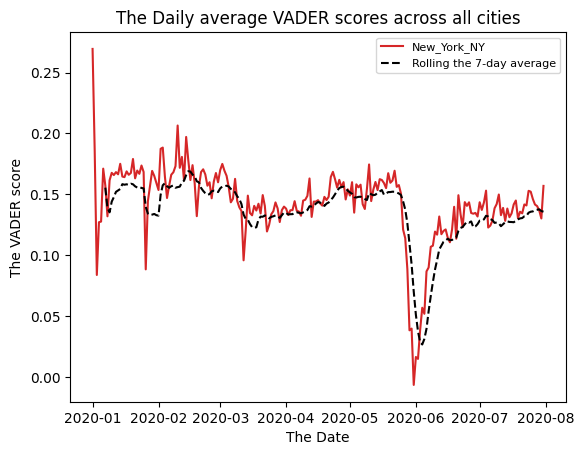

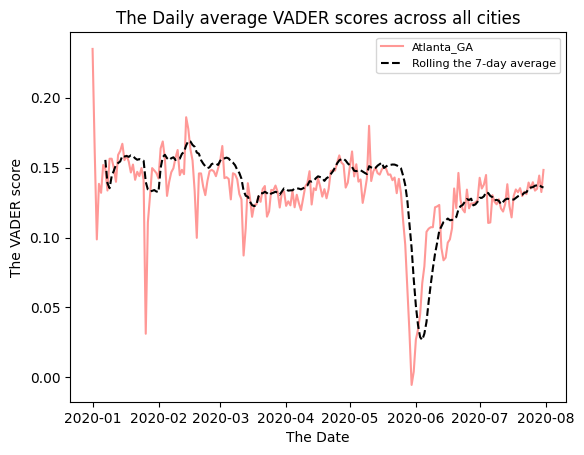

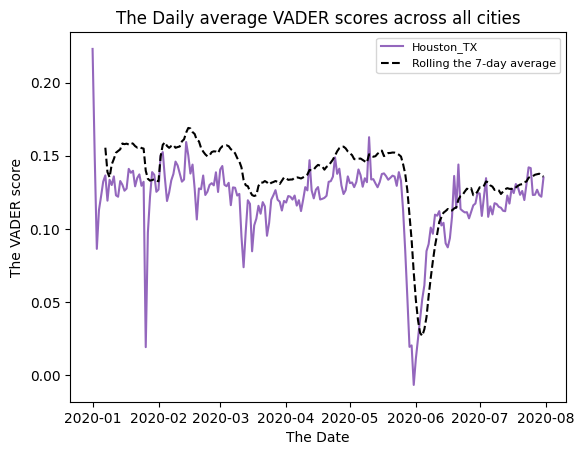

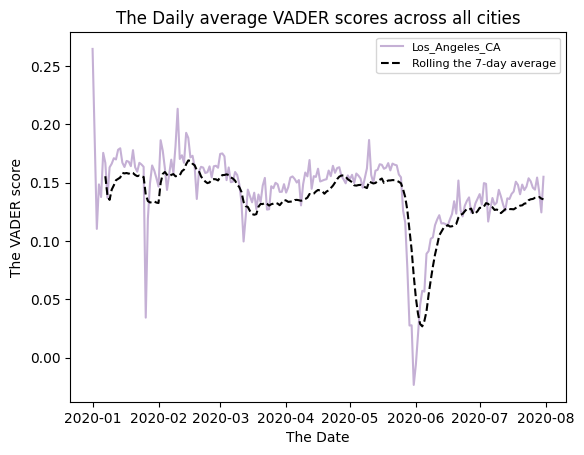

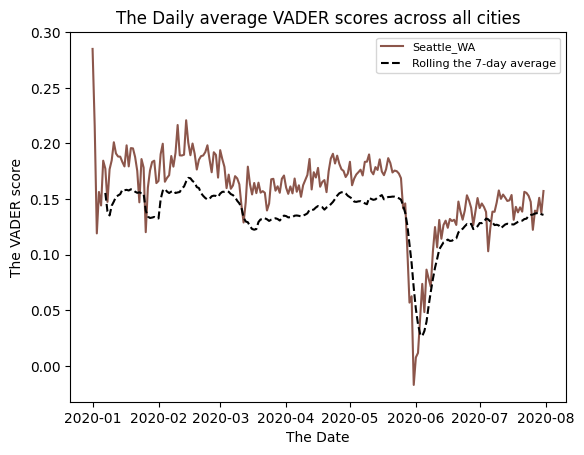

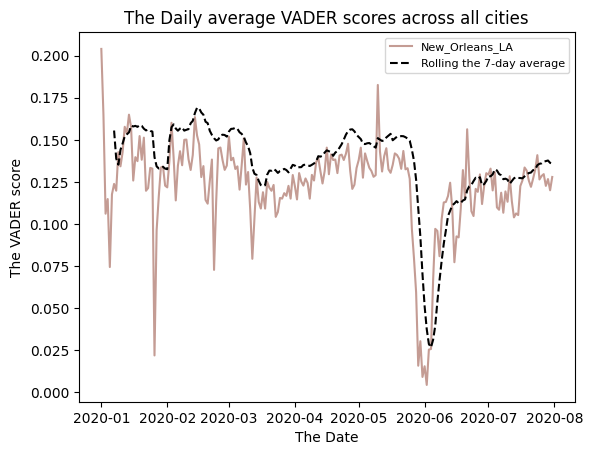

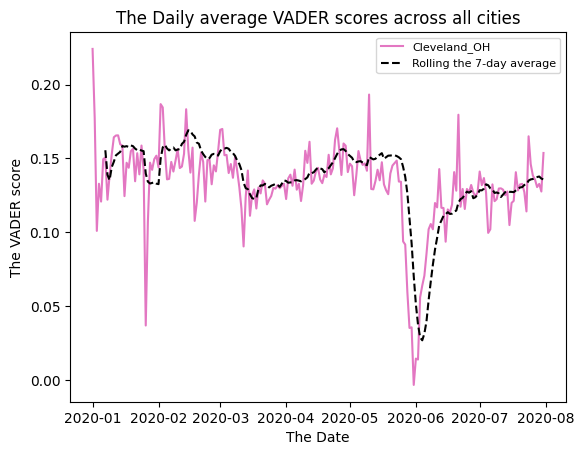

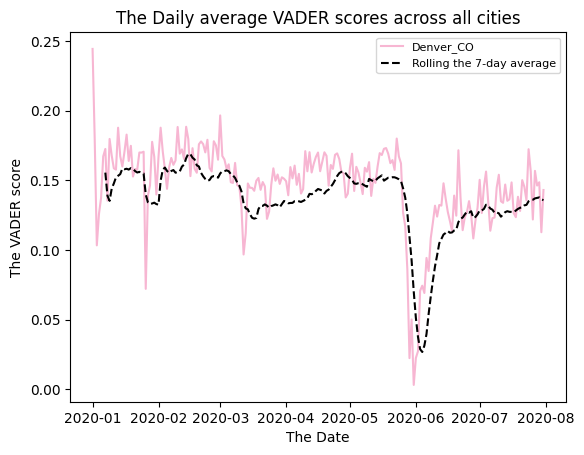

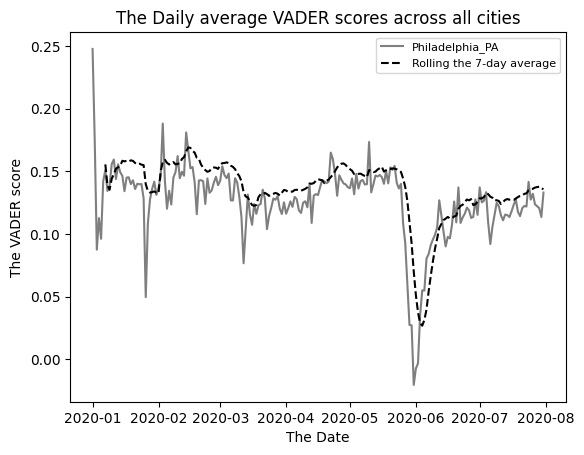

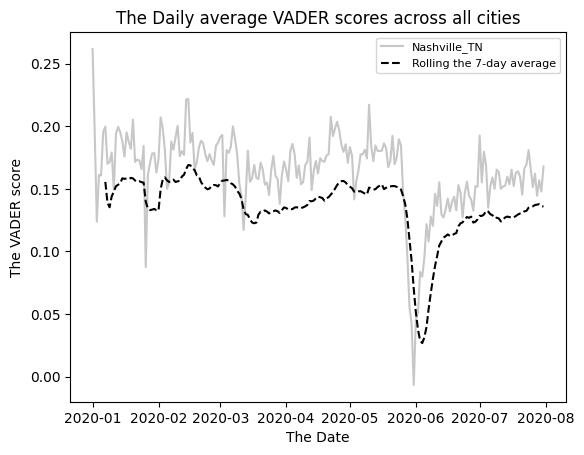

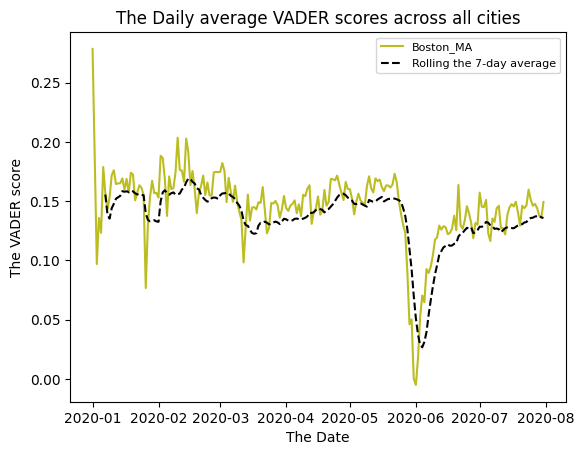

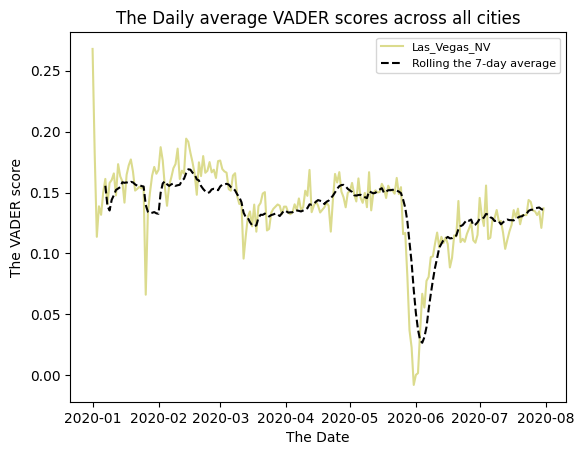

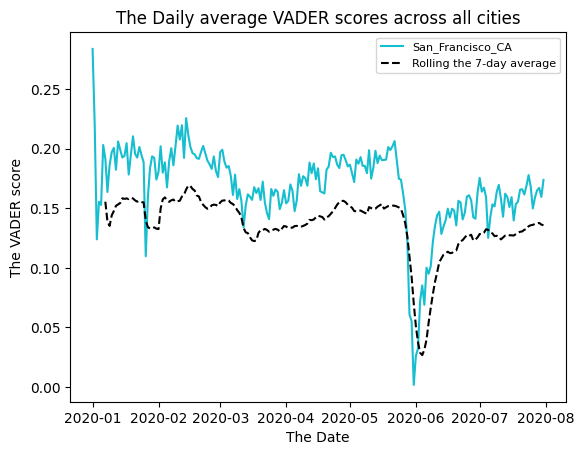

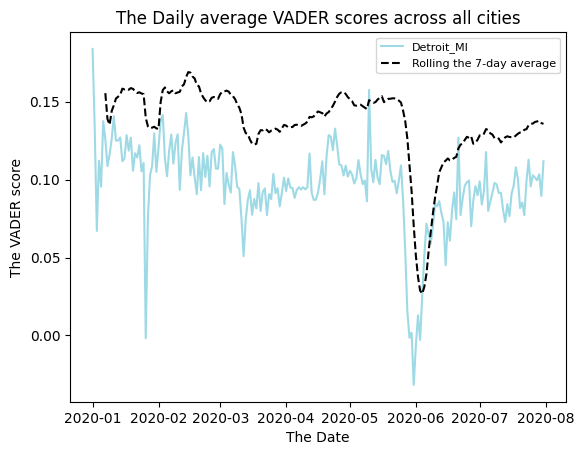

In [3]:
# I create the code with help of an AI-Tool.

means = pd.read_csv("HA4_daily_average_VADER.tsv", sep="\t", index_col=0, parse_dates=True)

counts = pd.read_csv("HA4_daily_num_obs.tsv", sep="\t", index_col=0, parse_dates=True)

daily_averages = means.mean(axis=1) 
rolling_avg = daily_averages.rolling(window=7).mean()

color_of_cities = plt.cm.tab20(range(len(means.columns)))



plt.figure() 
for i, city in enumerate(means.columns): 
    plt.plot(means[city], label=city, color = color_of_cities[i]) 
    plt.plot(rolling_avg, linestyle='--', color='black', label='Rolling the 7-day average') 
    plt.legend(fontsize=8, loc='upper right') 
    plt.xlabel('The Date') 
    plt.ylabel('The VADER score') 
    plt.title('The Daily average VADER scores across all cities') 
    plt.show()

### Exercise 2. (*2pt*)
Calculate the correlation coefficient between each city and the average time-series. Visualize the time-series that are the most and least correlated with the average time-series as scatter plots. Finally, include a dashed line plot (colored: black) that shows a rolling 7 day average of the overall average time series.

#### Solution

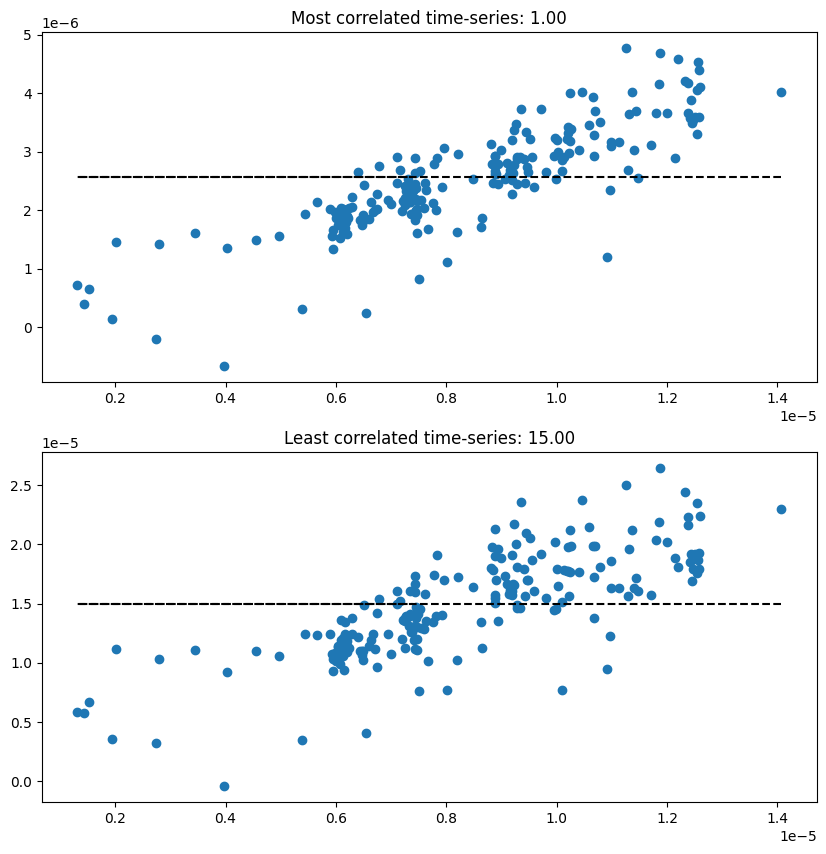

In [4]:
# I create the code with help of an AI-Tool.

daily_averagess = means.div(counts, axis=0)
overall_avg = daily_averagess.mean(axis=1)
rolling_avge = overall_avg.rolling(window=7).mean()

correlations = daily_averagess.corrwith(overall_avg)
correlations

fig, axs = plt.subplots(2, figsize=(10, 10))

axs[0].scatter(rolling_avge, daily_averagess.iloc[:, correlations.argmax()])
axs[0].set_title(f"Most correlated time-series: {correlations.argmax():.2f}")
axs[0].plot(rolling_avge, [daily_averagess.iloc[:, correlations.argmax()].mean()]*rolling_avge.shape[0], color='black', linestyle='--')


axs[1].scatter(rolling_avge, daily_averagess.iloc[:, correlations.argmin()])
axs[1].set_title(f"Least correlated time-series: {correlations.argmin():.2f}")
axs[1].plot(rolling_avge, [daily_averagess.iloc[:, correlations.argmin()].mean()]*rolling_avge.shape[0], color='black', linestyle='--')
plt.subplots_adjust(wspace=79.5)

plt.show()

### Exercise 3. (*2pt*)
In order to analyze the difference in societal mood before and after the COVID-19 pandemic hit, we will compare the VADER score before and after the date at which the WHO declared COVID-19 a pandemic (March 11th, 2020, stored in `_PANDEMIC_DATE`) for each city by calculating the average of the time-series both before and after March 11th, 2020. With these before and after averages per city, fit a regression model to predict the average mood after the WHO declared COVID-19 as a pandemic using the average mood before the WHO declared COVID-19 a pandemic. Print the summary of the fitted model. Finally, visualize the fitted model.

#### Solution

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     340.8
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           3.82e-13
Time:                        14:22:01   Log-Likelihood:                 82.821
No. Observations:                  20   AIC:                            -161.6
Df Residuals:                      18   BIC:                            -159.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.007      0.056      0.9

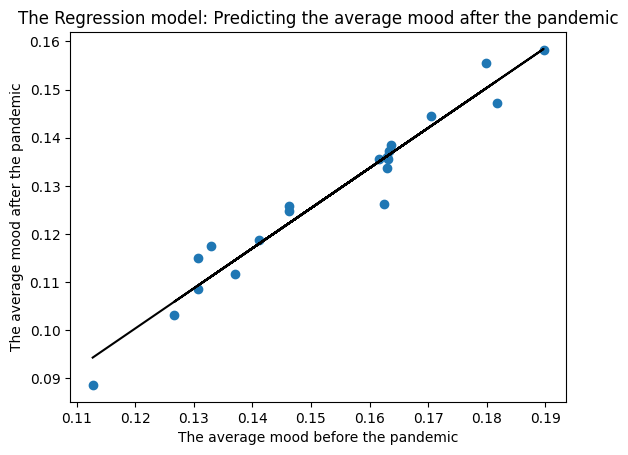

In [5]:
# I create the code with help of an AI-Tool.

import statsmodels.api as sm

pre_pandemic = means.loc[means.index < _PANDEMIC_DATE].mean(axis=0) 
post_pandemic = means.loc[means.index >= _PANDEMIC_DATE].mean(axis=0)


#Here
X = sm.add_constant(pre_pandemic) 
model = sm.OLS(post_pandemic.values, X).fit() 
print(model.summary())



plt.figure() 
plt.scatter(pre_pandemic, post_pandemic) 
plt.plot(pre_pandemic, model.predict(), color='black') 
plt.xlabel('The average mood before the pandemic') 
plt.ylabel('The average mood after the pandemic') 
plt.title('The Regression model: Predicting the average mood after the pandemic') 
plt.show()

### Exercise 4. (*3pt*)
As some cities were hit harder by the pandemic than others, we will investigate the impact of the demographic distribution on the difference in societal mood for all cities. Therefore, we need the demographic data that is contained in `HA4_demographics.tsv`. Using this information, determine the fraction of the population in each city that is white. Next, fit a regression model to predict the difference in average mood before and after the COVID-19 pandemic using the proportion of white inhabitants of a city. Print the summary of the fitted model. Finally, visualize the fitted model.

#### Solution

Model summary:
R 0.13412481869243098
Intercept: [-0.01890795]
Coefficients: [[-0.01185055]]


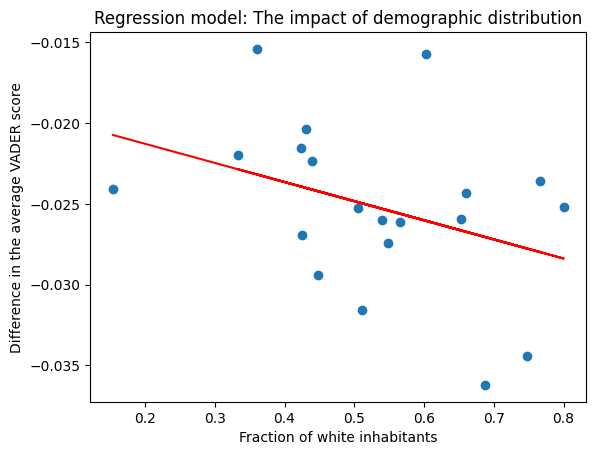

In [6]:
# I create the code with help of an AI-Tool.

from sklearn.linear_model import LinearRegression

demographics = pd.read_csv("HA4_demographics.tsv", sep="\t", index_col=0)
demographics
filtered_demographics = demographics[demographics['Race'] == 'White']


white_fraction = filtered_demographics["Count"] / filtered_demographics["Total Population"]



diff = post_pandemic - pre_pandemic


#Here
o = white_fraction.values.reshape(-1,1) 
p = diff.values.reshape(-1,1) 
model = LinearRegression().fit(o, p)



#Here
print("Model summary:") 
print(f"R {model.score(o, p)}") 
print(f"Intercept: {model.intercept_}") 
print(f"Coefficients: {model.coef_}")



plt.scatter(white_fraction, diff) 
plt.plot(white_fraction, model.predict(o), color="red") 
plt.xlabel("Fraction of white inhabitants") 
plt.ylabel("Difference in the average VADER score") 
plt.title("Regression model: The impact of demographic distribution") 
plt.show()